### Implementação do DBSCAN
Primeiro, precisamos estimar o parâmetro **Epsilon (eps)** utilizando o Gráfico k-distance (método do cotovelo para vizinhos). Para um dataset bidimensional (2D), a diretriz prática sugerida na aula é fixar **minPts = 5**.

In [25]:
# 1. Importação das bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [26]:
# =========================
# 1. CARREGAR DADOS
# =========================
df = pd.read_csv(
    r"C:\Users\gques\Documents\SPTECH_CODIGOS\ultimo-ano\tcc\backend\tabela_final\part-00000-ca4a34f2-1bd8-485a-bddf-3084ae83539c-c000.csv"
)

# =========================
# 2. SPLIT TEMPORAL
# =========================
split_date = pd.to_datetime("2018-07-01", utc=True)

date_col = pd.to_datetime(
    df["order_delivered_carrier_date"],
    utc=True
)

train_mask = date_col < split_date
test_mask = date_col >= split_date

df_train = df[train_mask].copy()
df_test = df[test_mask].copy()

print(f"Treino: {len(df_train):,} linhas")
print(f"Teste: {len(df_test):,} linhas")

# =========================
# 3. FEATURES
# =========================
colunas_remover = [
    # Vazamento de dados / multicolinearidade
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "interval_code_delivered_carrier",
    "order_delivered_customer_date",
    "interval_code_delivered_customer",
    "order_estimated_delivery_date",
    "shipping_limit_date",
    "is_holiday_in_7_days",
    "is_holiday_in_14_days",
    "had_holiday_7_days_ago",
    "had_holiday_14_days_ago",
    "delivered_on_time",
    "customer_city",
    "seller_city",
    "category_name",
    "review_score"
]

X_train = df_train.drop(columns=colunas_remover)
X_test = df_test.drop(columns=colunas_remover)

# =========================
# 4. TRATAMENTO DE NULOS
# =========================
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

print("\nShape treino:", X_train.shape)
print("Shape teste:", X_test.shape)

print("\nColunas utilizadas:")
print(X_train.columns.tolist())

Treino: 28,710 linhas
Teste: 5,114 linhas

Shape treino: (28710, 13)
Shape teste: (5114, 13)

Colunas utilizadas:
['holiday_at_purchase', 'days_since_last_holiday', 'days_until_next_holiday', 'purchase_hour', 'purchase_day_of_week', 'is_weekend', 'delivery_time_days', 'price', 'freight_value', 'product_weight_g', 'volume_cm3', 'distance_km', 'same_city']


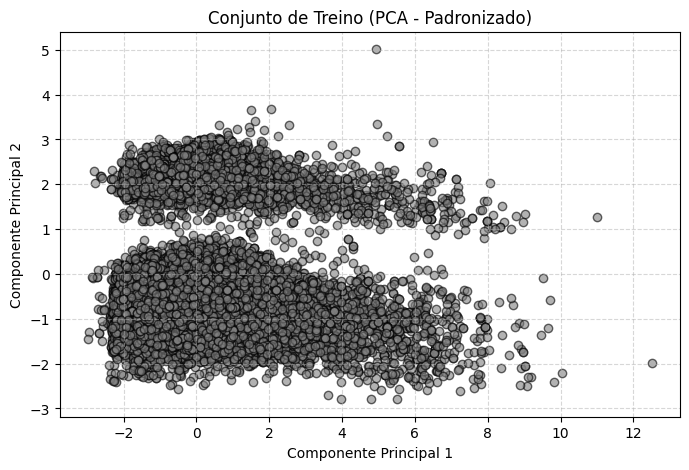

In [27]:
# # Padronização dos atributos
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # Redução para 2 dimensões apenas para visualização
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

# # Visualizando os dados reais
# plt.figure(figsize=(8, 5))
# plt.scatter(X_pca[:, 0], X_pca[:, 1], c='gray', alpha=0.6, edgecolors='k')
# plt.title('Conjunto de Dados Original (PCA - Padronizado)')
# plt.xlabel('Componente Principal 1')
# plt.ylabel('Componente Principal 2')
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.show()

# =========================
# PADRONIZAÇÃO DOS DADOS
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# REDUÇÃO PARA 2 DIMENSÕES
# (apenas para visualização)
# =========================
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# =========================
# VISUALIZAÇÃO DOS DADOS DE TREINO
# =========================
plt.figure(figsize=(8, 5))

plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c='gray',
    alpha=0.6,
    edgecolors='k'
)

plt.title('Conjunto de Treino (PCA - Padronizado)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

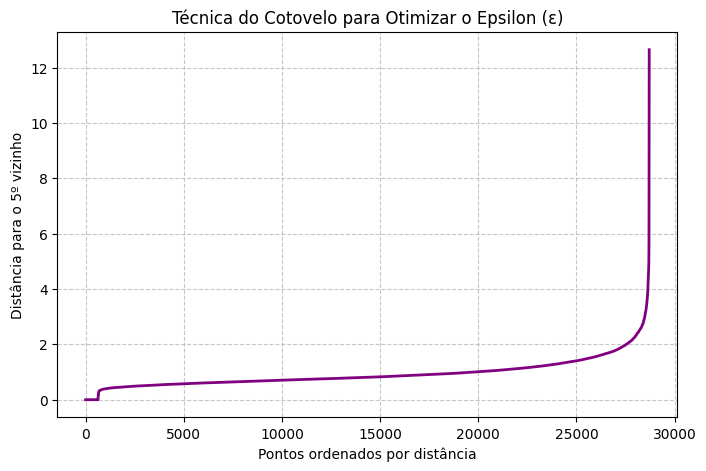

In [28]:
# Estimando vizinhos e plotando a técnica do cotovelo para o Epsilon
min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_train_scaled)

distances, indices = neighbors_fit.kneighbors(X_train_scaled)

# Distância até o 5º vizinho mais próximo
k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances, color='purple', linewidth=2)

plt.title('Técnica do Cotovelo para Otimizar o Epsilon (ε)')
plt.xlabel('Pontos ordenados por distância')
plt.ylabel(f'Distância para o {min_samples}º vizinho')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

Através do gráfico, notamos o "cotovelo" onde a distância salta subitamente, representando a transição de densidade alta para baixa. O valor adequado fica ao redor de `eps = 0.2`.

Clusters encontrados: 20
Outliers encontrados: 726


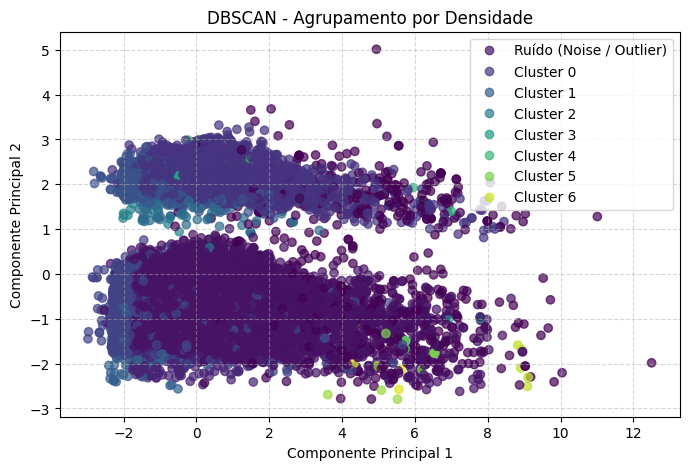

In [29]:
# Aplicando o DBSCAN
dbscan = DBSCAN(
    eps=2.0,
    min_samples=min_samples
)

dbscan_labels = dbscan.fit_predict(X_train_scaled)

# Quantidade de clusters encontrados
num_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
num_noise = np.sum(dbscan_labels == -1)

print(f"Clusters encontrados: {num_clusters}")
print(f"Outliers encontrados: {num_noise}")

# Visualizando o resultado do DBSCAN
plt.figure(figsize=(8, 5))

scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=dbscan_labels,
    cmap='viridis',
    alpha=0.7
)

plt.title('DBSCAN - Agrupamento por Densidade')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# Ajustando legenda
handles, _ = scatter.legend_elements()
unique_labels = np.unique(dbscan_labels)

new_labels = [
    f'Cluster {lbl}' if lbl >= 0
    else 'Ruído (Noise / Outlier)'
    for lbl in unique_labels
]

plt.legend(handles, new_labels, loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [30]:
for eps in [1.5, 2.0, 2.5, 3.0]:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X_train_scaled)

    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = np.sum(labels == -1)

    print(
        f"eps={eps} | "
        f"clusters={clusters} | "
        f"outliers={noise}"
    )

eps=1.5 | clusters=41 | outliers=2155
eps=2.0 | clusters=20 | outliers=726
eps=2.5 | clusters=9 | outliers=280
eps=3.0 | clusters=6 | outliers=130


In [31]:
resultado = df_train.copy()

resultado["cluster"] = dbscan_labels

pd.crosstab(
    resultado["cluster"],
    resultado["delivered_on_time"],
    normalize="index"
)

delivered_on_time,0,1
cluster,,
-1,0.217631,0.782369
0,0.046547,0.953453
1,0.023569,0.976431
2,0.044536,0.955464
3,0.046953,0.953047
4,0.034130,0.965870
5,0.049505,0.950495
6,0.040404,0.959596
7,0.000000,1.000000
